In [1]:
# conection to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# unziping dataset
!unzip /content/drive/MyDrive/data/Animals-10.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/raw-img/ragno/OIP-MVQChNQpHiMZEVMPehrvoAHaE6.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MVdIFDAFpNyK_XCpwkDIWgHaFj.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MYY_8k5AHqMJwTCNXfH6rwHaFj.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MZEVXuoMsATG8u_UuTQ6hAHaE8.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MZg0tznDRE95AMfyuutuYAHaE6.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-M_r9DkR2X5gP0P5-z8wPYQHaE7.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-M_xDUSzjlF3-w9XHCm93cgHaFF.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MbI4-bMyutRX3X382IAVcQAAAA.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MbMksZdD7gomsC9fd6cpKgHaHJ.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-Md4AMcvjaHcivJqeW06wEwHaFW.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MgCgailkT5XkO1XczzQCngHaLK.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP

In [3]:
# imports
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import os
from PIL import Image
from collections import Counter

import torch
import torchvision
import torchvision.datasets
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
from torchvision.io import read_image

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# **loading data**

In [4]:
# counting number of images in classes
path = '/content/dataset/raw-img'
classes = os.listdir(path)

class_names = {}
for class_name in classes:
  class_names[class_name] = len(os.listdir(os.path.join(path, class_name)))

class_names

{'pecora': 1820,
 'gallina': 3098,
 'ragno': 4821,
 'cavallo': 2623,
 'cane': 4863,
 'elefante': 1446,
 'scoiattolo': 1862,
 'farfalla': 2112,
 'mucca': 1866,
 'gatto': 1668}

In [5]:
# sorting classes distribution for visualization
class_names_sorted = dict(reversed(sorted(class_names.items(), key=lambda item: item[1])))
class_names_sorted

{'cane': 4863,
 'ragno': 4821,
 'gallina': 3098,
 'cavallo': 2623,
 'farfalla': 2112,
 'mucca': 1866,
 'scoiattolo': 1862,
 'pecora': 1820,
 'gatto': 1668,
 'elefante': 1446}

In [6]:
IMAGE_SIZE = (64, 64)
MEANS = [0.517645001411438, 0.5002366304397583, 0.4124912917613983]
STDS = [0.2544998228549957, 0.2494899481534958, 0.2677474021911621]

In [7]:
# conversion to tensors
transform_test = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),                                   # setting one size for all images
    transforms.ToTensor(),                                           # converting to tensors
    transforms.Normalize(mean=MEANS, std=STDS)
])

In [8]:
# conversion to tensors
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),        # setting one size for all images
    transforms.RandomHorizontalFlip(),    # random horiz flip of images
    transforms.RandomRotation(15),        # random rotation
    transforms.ToTensor(),                # converting to tensors
    transforms.Normalize(mean=MEANS, std=STDS)
])

In [9]:
# loading dataset
data = torchvision.datasets.ImageFolder(root='/content/dataset/raw-img', transform=None)

In [10]:
# getting classes names
classes = data.classes
print(f'data classes: {classes}, number of classes: {len(classes)}')

data classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo'], number of classes: 10


In [11]:
# transtating classes to english
translate = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat", "mucca": "cow",
             "pecora": "sheep", "ragno": "spider", "scoiattolo": "squirrel"}
classes_eng = [translate[animal] for animal in translate]

In [12]:
print(f'data classes: {classes_eng}, number of classes: {len(classes_eng)}')

data classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel'], number of classes: 10


In [13]:
data.classes

['cane',
 'cavallo',
 'elefante',
 'farfalla',
 'gallina',
 'gatto',
 'mucca',
 'pecora',
 'ragno',
 'scoiattolo']

In [14]:
data.class_to_idx

{'cane': 0,
 'cavallo': 1,
 'elefante': 2,
 'farfalla': 3,
 'gallina': 4,
 'gatto': 5,
 'mucca': 6,
 'pecora': 7,
 'ragno': 8,
 'scoiattolo': 9}

In [15]:
counter = Counter(data.targets)
counter, data.class_to_idx

(Counter({0: 4863,
          1: 2623,
          2: 1446,
          3: 2112,
          4: 3098,
          5: 1668,
          6: 1866,
          7: 1820,
          8: 4821,
          9: 1862}),
 {'cane': 0,
  'cavallo': 1,
  'elefante': 2,
  'farfalla': 3,
  'gallina': 4,
  'gatto': 5,
  'mucca': 6,
  'pecora': 7,
  'ragno': 8,
  'scoiattolo': 9})

# **dividing dataset to train and test**

In [16]:
def count_classes(dataset):
    labels = [dataset.dataset.targets[i] for i in dataset.indices]
    class_counts = Counter(labels)
    for class_idx, count in class_counts.items():
        class_name = dataset.dataset.classes[class_idx]
        print(f"Class:\t{class_name} ({classes_eng[class_idx]}),\t\tInstances: {count}, \tPercent: {count / counter[class_idx] * 100}%")

In [17]:
# dividing dataset to train, validation and test
train_size = int(len(data) * 0.6)
test_size = int(len(data) * 0.2)
val_size = int(len(data) - train_size - test_size)

train_data, test_data, valid_data = random_split(dataset=data, lengths=[train_size, test_size, val_size])
print(f'train: {len(train_data)}, test: {len(test_data)}, validation: {len(valid_data)}')

train: 15707, test: 5235, validation: 5237


In [18]:
count_classes(train_data)

Class:	scoiattolo (squirrel),		Instances: 1162, 	Percent: 62.40601503759399%
Class:	cane (dog),		Instances: 2935, 	Percent: 60.35369113715813%
Class:	ragno (spider),		Instances: 2932, 	Percent: 60.81725783032566%
Class:	farfalla (butterfly),		Instances: 1248, 	Percent: 59.09090909090909%
Class:	gallina (chicken),		Instances: 1837, 	Percent: 59.296320206584895%
Class:	gatto (cat),		Instances: 970, 	Percent: 58.153477218225426%
Class:	cavallo (horse),		Instances: 1583, 	Percent: 60.35074342356081%
Class:	pecora (sheep),		Instances: 1100, 	Percent: 60.43956043956044%
Class:	mucca (cow),		Instances: 1073, 	Percent: 57.502679528403%
Class:	elefante (elephant),		Instances: 867, 	Percent: 59.95850622406639%


In [19]:
count_classes(test_data)

Class:	cane (dog),		Instances: 952, 	Percent: 19.576393172938516%
Class:	elefante (elephant),		Instances: 297, 	Percent: 20.539419087136928%
Class:	gallina (chicken),		Instances: 603, 	Percent: 19.46417043253712%
Class:	mucca (cow),		Instances: 376, 	Percent: 20.15005359056806%
Class:	farfalla (butterfly),		Instances: 442, 	Percent: 20.928030303030305%
Class:	ragno (spider),		Instances: 973, 	Percent: 20.18253474382908%
Class:	cavallo (horse),		Instances: 529, 	Percent: 20.167746854746476%
Class:	scoiattolo (squirrel),		Instances: 349, 	Percent: 18.743286788399573%
Class:	pecora (sheep),		Instances: 366, 	Percent: 20.10989010989011%
Class:	gatto (cat),		Instances: 348, 	Percent: 20.863309352517987%


In [20]:
count_classes(valid_data)

Class:	elefante (elephant),		Instances: 282, 	Percent: 19.502074688796682%
Class:	cavallo (horse),		Instances: 511, 	Percent: 19.48150972169272%
Class:	cane (dog),		Instances: 976, 	Percent: 20.069915689903354%
Class:	gallina (chicken),		Instances: 658, 	Percent: 21.239509360877985%
Class:	gatto (cat),		Instances: 350, 	Percent: 20.983213429256594%
Class:	mucca (cow),		Instances: 417, 	Percent: 22.347266881028936%
Class:	farfalla (butterfly),		Instances: 422, 	Percent: 19.981060606060606%
Class:	scoiattolo (squirrel),		Instances: 351, 	Percent: 18.850698174006446%
Class:	ragno (spider),		Instances: 916, 	Percent: 19.00020742584526%
Class:	pecora (sheep),		Instances: 354, 	Percent: 19.450549450549453%


## **adding transformation to datasets**

In [21]:
class SubsetWithTransform():
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

In [22]:
train_data = SubsetWithTransform(train_data, transform=transform)
test_data = SubsetWithTransform(test_data, transform=transform_test)
valid_data = SubsetWithTransform(valid_data, transform=transform)

In [23]:
train_data.transform, test_data.transform, valid_data.transform

(Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
     ToTensor()
     Normalize(mean=[0.517645001411438, 0.5002366304397583, 0.4124912917613983], std=[0.2544998228549957, 0.2494899481534958, 0.2677474021911621])
 ),
 Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=[0.517645001411438, 0.5002366304397583, 0.4124912917613983], std=[0.2544998228549957, 0.2494899481534958, 0.2677474021911621])
 ),
 Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
     ToTensor()
     Normalize(mean=[0.517645001411438, 0.5002366304397583, 0.4124912917613983], std=[0.2544998228549957, 0.2494899481534958, 0.2677

## **creating data loaders**

In [24]:
num_workers = 2

In [25]:
batch_size=64

In [26]:
# creating data loader
data_loader = DataLoader(dataset=data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
data_loader

In [27]:
# creating data loader for test and train data
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [28]:
# creating data loader for validation data
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# **part 3**

In [29]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=10, in_channels=3, filters=[32, 64, 128, 256], fc_units=[512, 256, 128]):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, filters[0], kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(filters[0])
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(filters[0], filters[1], kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(filters[1])
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(filters[1], filters[2], kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(filters[2])
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv4 = nn.Conv2d(filters[2], filters[3], kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(filters[3])
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self._to_linear = None
        self.convs(torch.zeros(1, in_channels, 64, 64))

        self.fc1 = nn.Linear(self._to_linear, fc_units[0])
        self.fc2 = nn.Linear(fc_units[0], fc_units[1])
        self.fc3 = nn.Linear(fc_units[1], fc_units[2])
        self.fc4 = nn.Linear(fc_units[2], num_classes)

    def convs(self, x):
        x = F.relu(self.conv1(x))
        x = self.bn1(x)
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.bn2(x)
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.bn3(x)
        x = self.pool3(x)
        x = F.relu(self.conv4(x))
        x = self.bn4(x)
        x = self.pool4(x)

        if self._to_linear is None:
            self._to_linear = x.view(x.size(0), -1).size(1)
        return x

    def forward(self, x):
        x = self.convs(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [30]:
model = CNNModel()
model

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

In [31]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
model.to(device)

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

In [32]:
loss_function = nn.CrossEntropyLoss()

In [33]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [34]:
number_epochs = 10
number_epochs

10

In [35]:
len(valid_data), valid_loader.batch_size

(5237, 64)

In [36]:
print(f'Model: {model},\n\nLoss function: {loss_function},\n\nOptimizer: {optimizer},\n\nScheduler: {scheduler}')

Model: CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, 

In [37]:
def evaluate_metrics(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return accuracy * 100, precision, recall, f1

In [38]:
train_loss_list = []
val_loss_list = []
train_metrics = {metric: [] for metric in ['accuracy', 'f1_score', 'recall_score', 'precision']}
val_metrics = {metric: [] for metric in ['accuracy', 'f1_score', 'recall_score', 'precision']}

In [39]:
def train_epoch():
  model.train()
  train_loss = torch.tensor(0.0, device=device)

  for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = loss_function(outputs, labels)
      loss.backward()
      optimizer.step()
      train_loss += loss.item()

  train_loss = train_loss.item() / len(train_loader)
  train_loss_list.append(train_loss)

  train_accuracy, train_precision, train_recall, train_f1 = evaluate_metrics(model, train_loader)
  train_metrics['accuracy'].append(train_accuracy)
  train_metrics['f1_score'].append(train_f1)
  train_metrics['recall_score'].append(train_recall)
  train_metrics['precision'].append(train_precision)
  return train_loss, train_accuracy, train_precision, train_recall, train_f1

In [40]:
def eval_epoch():
  model.eval()
  val_loss = torch.tensor(0.0, device=device)

  with torch.no_grad():
      for images, labels in valid_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = loss_function(outputs, labels)
          val_loss += loss.item()

  val_loss = val_loss.item() / len(valid_loader)
  val_loss_list.append(val_loss)

  val_accuracy, val_precision, val_recall, val_f1 = evaluate_metrics(model, valid_loader)
  val_metrics['accuracy'].append(val_accuracy)
  val_metrics['f1_score'].append(val_f1)
  val_metrics['recall_score'].append(val_recall)
  val_metrics['precision'].append(val_precision)
  return val_loss, val_accuracy, val_precision, val_recall, val_f1

In [41]:
for epoch in range(number_epochs):

    train_loss, train_accuracy, train_precision, train_recall, train_f1 = train_epoch()
    val_loss, val_accuracy, val_precision, val_recall, val_f1 = eval_epoch()
    scheduler.step()

    print(f"Epoch {epoch+1}/{number_epochs}:"
          f"\n\tTrain Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%,"
          f"\n\tTrain Precision: {train_precision:.4f}, Train Recall: {train_recall:.4f}, Train F1-score: {train_f1:.4f}"
          f"\n\tVal Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%,"
          f"\n\tVal Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, Val F1-score: {val_f1:.4f}\n")

Epoch 1/10:
	Train Loss: 1.6391, Train Accuracy: 52.29%,
	Train Precision: 0.5106, Train Recall: 0.4602, Train F1-score: 0.4448
	Val Loss: 1.4327, Validation Accuracy: 50.62%,
	Val Precision: 0.4988, Val Recall: 0.4479, Val F1-score: 0.4254

Epoch 2/10:
	Train Loss: 1.2397, Train Accuracy: 62.31%,
	Train Precision: 0.6465, Train Recall: 0.5501, Train F1-score: 0.5578
	Val Loss: 1.1819, Validation Accuracy: 59.54%,
	Val Precision: 0.6093, Val Recall: 0.5182, Val F1-score: 0.5242

Epoch 3/10:
	Train Loss: 1.0435, Train Accuracy: 67.43%,
	Train Precision: 0.6564, Train Recall: 0.6561, Train F1-score: 0.6416
	Val Loss: 1.0884, Validation Accuracy: 62.90%,
	Val Precision: 0.6068, Val Recall: 0.6114, Val F1-score: 0.5939

Epoch 4/10:
	Train Loss: 0.9311, Train Accuracy: 71.96%,
	Train Precision: 0.7023, Train Recall: 0.7047, Train F1-score: 0.6975
	Val Loss: 1.0069, Validation Accuracy: 66.28%,
	Val Precision: 0.6409, Val Recall: 0.6423, Val F1-score: 0.6356

Epoch 5/10:
	Train Loss: 0.8163,

Text(0.5, 1.0, 'Train Recall Score')

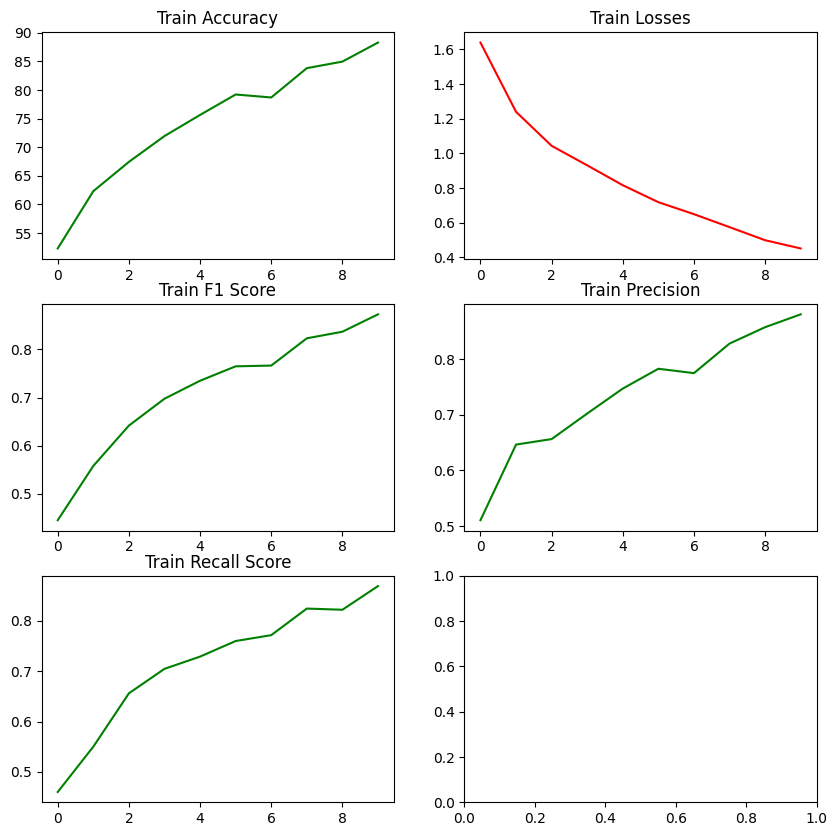

In [42]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0,0].plot(train_metrics['accuracy'], color='g')
ax[0,0].set_title('Train Accuracy')

ax[0,1].plot(train_loss_list, color='r')
ax[0,1].set_title('Train Losses')

ax[1,0].plot(train_metrics['f1_score'], color='g')
ax[1,0].set_title('Train F1 Score')

ax[1,1].plot(train_metrics['precision'], color='g')
ax[1,1].set_title('Train Precision')

ax[2,0].plot(train_metrics['recall_score'], color='g')
ax[2,0].set_title('Train Recall Score')

Text(0.5, 1.0, 'Validation Recall Score')

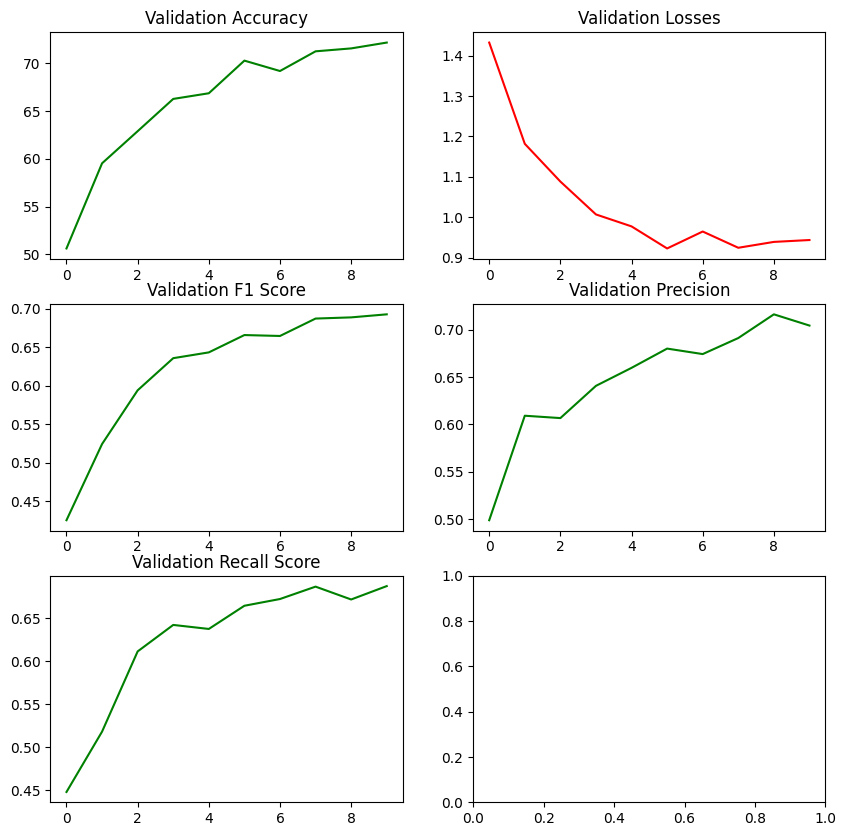

In [43]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0,0].plot(val_metrics['accuracy'], color='g')
ax[0,0].set_title('Validation Accuracy')

ax[0,1].plot(val_loss_list, color='r')
ax[0,1].set_title('Validation Losses')

ax[1,0].plot(val_metrics['f1_score'], color='g')
ax[1,0].set_title('Validation F1 Score')

ax[1,1].plot(val_metrics['precision'], color='g')
ax[1,1].set_title('Validation Precision')

ax[2,0].plot(val_metrics['recall_score'], color='g')
ax[2,0].set_title('Validation Recall Score')

In [44]:
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

In [45]:
print(all_labels)
print(all_preds)

[np.int64(0), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(4), np.int64(6), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(4), np.int64(8), np.int64(1), np.int64(1), np.int64(9), np.int64(4), np.int64(8), np.int64(8), np.int64(9), np.int64(8), np.int64(0), np.int64(6), np.int64(1), np.int64(0), np.int64(1), np.int64(7), np.int64(4), np.int64(4), np.int64(0), np.int64(8), np.int64(1), np.int64(8), np.int64(9), np.int64(4), np.int64(4), np.int64(8), np.int64(8), np.int64(8), np.int64(0), np.int64(0), np.int64(5), np.int64(3), np.int64(2), np.int64(8), np.int64(7), np.int64(6), np.int64(1), np.int64(7), np.int64(6), np.int64(6), np.int64(2), np.int64(0), np.int64(5), np.int64(0), np.int64(9), np.int64(7), np.int64(7), np.int64(0), np.int64(5), np.int64(9), np.int64(8), np.int64(1), np.int64(8), np.int64(8), np.int64(7), np.int64(8), np.int64(6), np.int64(7), np.int64(4), np.int64(5), np.int64(1), np.int64(8), np.int64(5), np.int64(0), np.int64(9), np.int64(1)

In [46]:
count_similar = 0
for i in range(len(all_labels)):
  if all_labels[i] == all_preds[i]:
    count_similar += 1

count_similar

3870

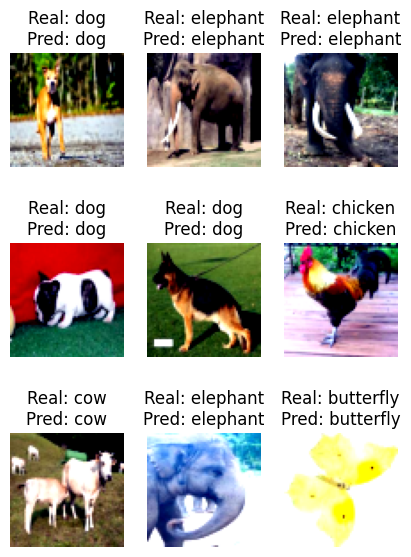

In [47]:
fig, axes = plt.subplots(3, 3, figsize=(5, 7))
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = outputs.max(1)

for i, ax in enumerate(axes.flat):
    img = images[i]
    img = img / 2 + 0.5
    img = img.cpu().numpy().transpose((1, 2, 0))
    ax.imshow(img)
    ax.set_title(f'Real: {classes_eng[labels[i].item()]}\nPred: {classes_eng[predicted[i].item()]}')
    ax.axis('off')
plt.show()

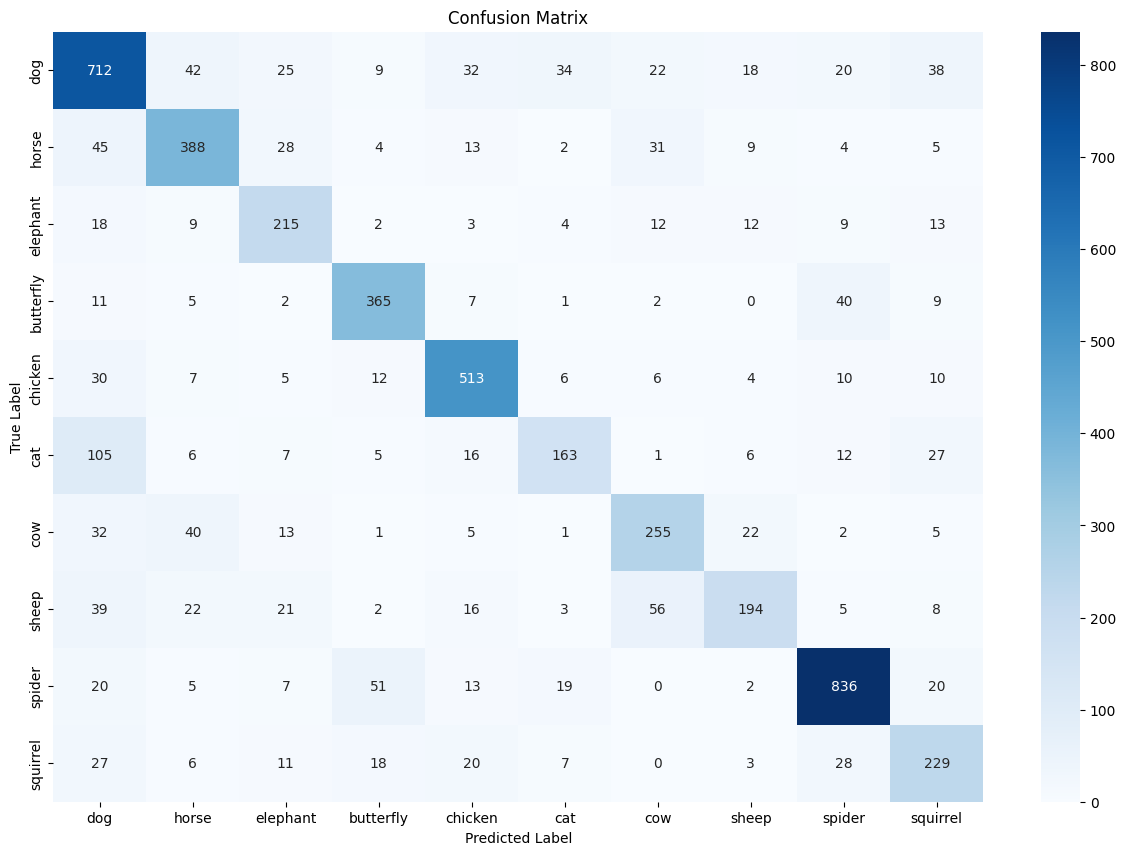

In [48]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes_eng, yticklabels=classes_eng)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [51]:
print(classification_report(all_labels, all_preds, target_names=classes_eng))

              precision    recall  f1-score   support

         dog       0.69      0.75      0.72       952
       horse       0.73      0.73      0.73       529
    elephant       0.64      0.72      0.68       297
   butterfly       0.78      0.83      0.80       442
     chicken       0.80      0.85      0.83       603
         cat       0.68      0.47      0.55       348
         cow       0.66      0.68      0.67       376
       sheep       0.72      0.53      0.61       366
      spider       0.87      0.86      0.86       973
    squirrel       0.63      0.66      0.64       349

    accuracy                           0.74      5235
   macro avg       0.72      0.71      0.71      5235
weighted avg       0.74      0.74      0.74      5235

